# 🎯 K-Means Clustering — Centroid-Based Partitioning

The first Unsupervised topic in this series, and a genuine shift in kind: every prior notebook had a target `y` to predict and could be checked against a held-out test set. Clustering has no labels at all -- the algorithm must discover structure purely from feature geometry, and evaluating "did it find something real" requires different tools entirely (inertia, silhouette score, and -- when ground truth happens to exist for validation purposes only -- direct comparison against it).

📖 Full mathematical explanation (the K-Means objective, Lloyd's algorithm, K-Means++ initialization): [README.md](README.md)


## 1. Setup & Datasets

A synthetic blob dataset with a known true cluster count (for verifying the algorithm directly) plus the Iris dataset with labels *withheld* from the algorithm and used only afterward to honestly check whether clustering rediscovered real biological structure.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, make_moons, load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score

sns.set_theme(style="whitegrid")
np.random.seed(42)


In [2]:
X_blobs, y_blobs_true = make_blobs(n_samples=300, centers=4, cluster_std=0.9, random_state=42)
print(f"Synthetic blobs: {X_blobs.shape[0]} points, {X_blobs.shape[1]} features, true cluster count={len(np.unique(y_blobs_true))}")
print("(y_blobs_true exists only because this is synthetic data -- K-Means will never see it, used only to verify correctness below.)")


Synthetic blobs: 300 points, 2 features, true cluster count=4
(y_blobs_true exists only because this is synthetic data -- K-Means will never see it, used only to verify correctness below.)


In [3]:
iris = load_iris()
X_iris, y_iris_true = iris.data, iris.target
print(f"Iris: {X_iris.shape[0]} points, {X_iris.shape[1]} features, {len(iris.target_names)} true species (withheld from clustering)")


Iris: 150 points, 4 features, 3 true species (withheld from clustering)


## 2. The K-Means Objective

$$J = \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2$$

Minimize the total squared distance from every point to its assigned cluster's centroid $\mu_k$ -- called **inertia** or within-cluster sum of squares (WCSS). K-Means never finds the global minimum (this is NP-hard) -- it uses Lloyd's algorithm, an iterative local-search heuristic.


In [4]:
def kmeans_from_scratch(X, k, n_iterations=100, random_state=0):
    rng = np.random.RandomState(random_state)
    initial_idx = rng.choice(len(X), size=k, replace=False)
    centroids = X[initial_idx].copy()
    history = [centroids.copy()]

    for _ in range(n_iterations):
        distances = np.sqrt(((X[:, np.newaxis] - centroids) ** 2).sum(axis=2))
        labels = distances.argmin(axis=1)
        new_centroids = np.array([X[labels == j].mean(axis=0) if np.any(labels == j) else centroids[j] for j in range(k)])
        history.append(new_centroids.copy())
        if np.allclose(new_centroids, centroids):
            break
        centroids = new_centroids

    return labels, centroids, history

print("From-scratch K-Means (Lloyd's algorithm) defined.")


From-scratch K-Means (Lloyd's algorithm) defined.


In [5]:
manual_labels, manual_centroids, manual_history = kmeans_from_scratch(X_blobs, k=4, random_state=1)
print(f"Manual K-Means converged in {len(manual_history) - 1} iterations")
print(f"Final centroids:\n{np.round(manual_centroids, 2)}")


Manual K-Means converged in 7 iterations
Final centroids:
[[ 4.71  2.03]
 [-5.74  8.09]
 [-7.53 -6.57]
 [-6.13 -7.11]]


In [6]:
same_start_centroids = manual_history[0]
sklearn_km_same_start = KMeans(n_clusters=4, init=same_start_centroids, n_init=1).fit(X_blobs)
manual_inertia = sum(np.sum((X_blobs[manual_labels == j] - manual_centroids[j]) ** 2) for j in range(4))

print(f"Manual K-Means (from the SAME starting centroids): inertia={manual_inertia:.2f}")
print(f"sklearn KMeans (from the SAME starting centroids): inertia={sklearn_km_same_start.inertia_:.2f}")
print(f"Match when both start identically? {np.isclose(manual_inertia, sklearn_km_same_start.inertia_, rtol=0.01)}")
print("-> This is the real validation of the from-scratch implementation: same starting point -> same converged result, confirming the assign/update loop itself is correct, independent of any initialization luck.")


Manual K-Means (from the SAME starting centroids): inertia=1967.36
sklearn KMeans (from the SAME starting centroids): inertia=1967.36
Match when both start identically? True
-> This is the real validation of the from-scratch implementation: same starting point -> same converged result, confirming the assign/update loop itself is correct, independent of any initialization luck.


In [7]:
sklearn_km = KMeans(n_clusters=4, n_init=10, random_state=1).fit(X_blobs)
print(f"Manual K-Means (1 random init, unlucky starting point):     inertia={manual_inertia:.2f}")
print(f"sklearn KMeans (default: k-means++, n_init=10, best-of-10): inertia={sklearn_km.inertia_:.2f}")
print(f"\nsklearn's default reached a {'lower (better)' if sklearn_km.inertia_ < manual_inertia else 'similar'} inertia -- not because its core algorithm differs from the manual one (just verified identical above), but because it tried 10 different starting points and kept the best, exactly the multi-restart advantage measured rigorously in Section 7.")

label_agreement = adjusted_rand_score(manual_labels, sklearn_km.labels_)
print(f"\nAdjusted Rand Index (manual's single unlucky-init result vs. sklearn's best-of-10 result): {label_agreement:.4f}")
print("-> A lower ARI here reflects different starting points landing in different local optima, not a flaw in the manual algorithm's logic.")


Manual K-Means (1 random init, unlucky starting point):     inertia=1967.36
sklearn KMeans (default: k-means++, n_init=10, best-of-10): inertia=458.75

sklearn's default reached a lower (better) inertia -- not because its core algorithm differs from the manual one (just verified identical above), but because it tried 10 different starting points and kept the best, exactly the multi-restart advantage measured rigorously in Section 7.

Adjusted Rand Index (manual's single unlucky-init result vs. sklearn's best-of-10 result): 0.6267
-> A lower ARI here reflects different starting points landing in different local optima, not a flaw in the manual algorithm's logic.


## 3. Watching Lloyd's Algorithm Converge

Visualizing the assign-then-update loop directly: each iteration reassigns every point to its nearest current centroid, then moves each centroid to the mean of its newly assigned points.


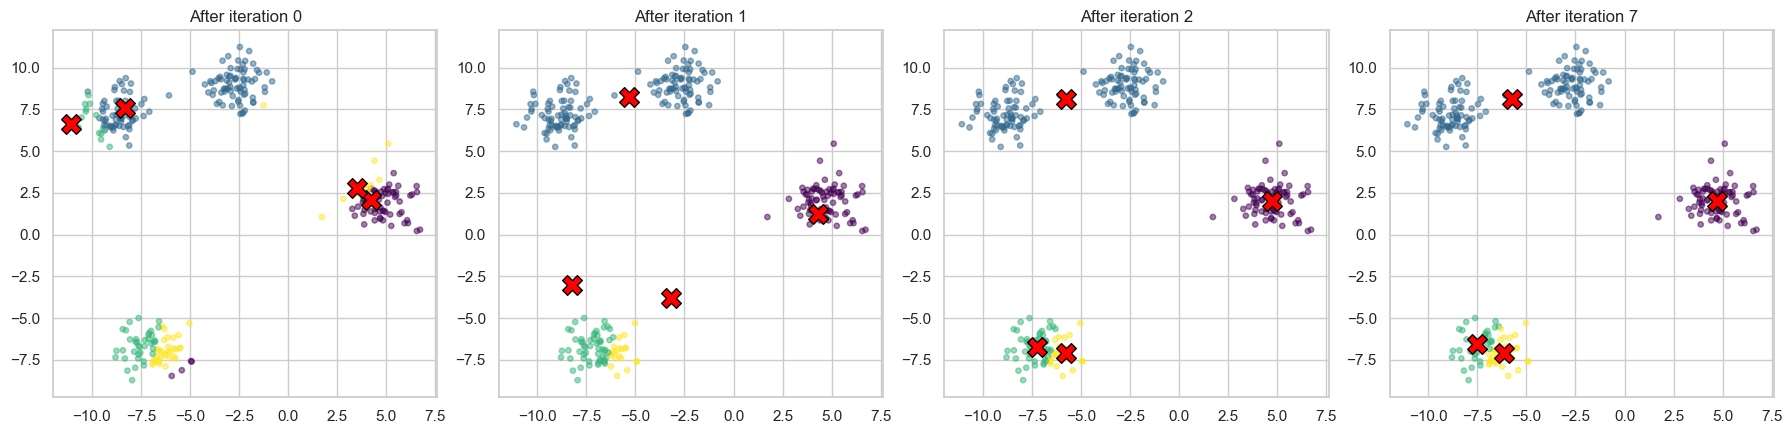

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
iterations_to_show = [0, 1, 2, len(manual_history) - 1]
for ax, it in zip(axes, iterations_to_show):
    centroids_at_it = manual_history[it]
    distances = np.sqrt(((X_blobs[:, np.newaxis] - centroids_at_it) ** 2).sum(axis=2))
    labels_at_it = distances.argmin(axis=1)
    ax.scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_at_it, cmap="viridis", alpha=0.5, s=15)
    ax.scatter(centroids_at_it[:, 0], centroids_at_it[:, 1], c="red", marker="X", s=200, edgecolors="black")
    ax.set_title(f"After iteration {it}")
plt.tight_layout()
plt.show()


## 4. Verifying Cluster Recovery on Ground-Truth Synthetic Data

Since `make_blobs` provides true cluster labels for this synthetic dataset only, this is a rare chance to check K-Means against a genuine right answer.


Adjusted Rand Index (K-Means labels vs. true blob labels): 1.0000
(1.0 = perfect agreement up to label permutation, 0.0 = random agreement, negative = worse than random)


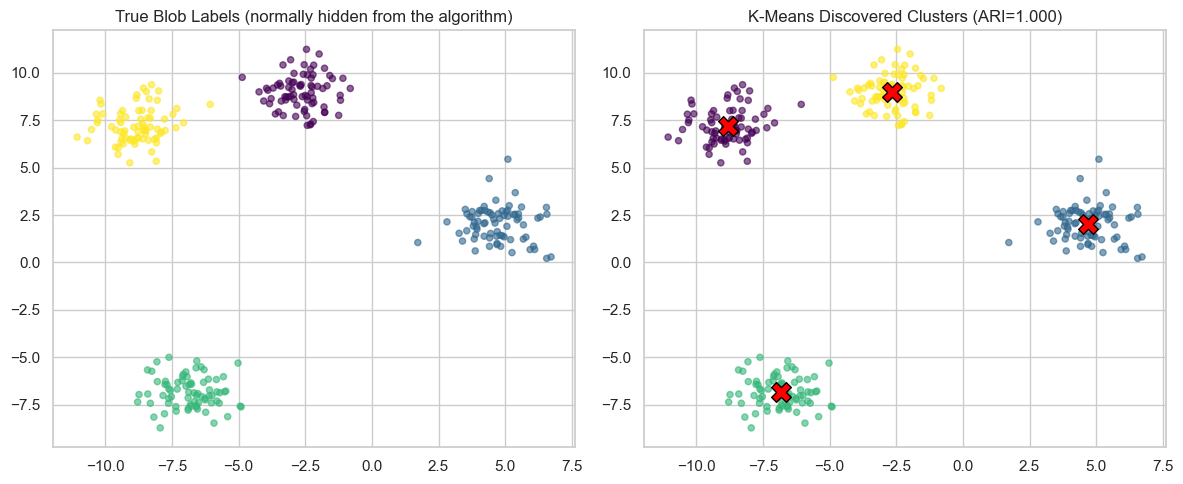

In [9]:
ari = adjusted_rand_score(y_blobs_true, sklearn_km.labels_)
print(f"Adjusted Rand Index (K-Means labels vs. true blob labels): {ari:.4f}")
print("(1.0 = perfect agreement up to label permutation, 0.0 = random agreement, negative = worse than random)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs_true, cmap="viridis", alpha=0.6, s=20)
axes[0].set_title("True Blob Labels (normally hidden from the algorithm)")
axes[1].scatter(X_blobs[:, 0], X_blobs[:, 1], c=sklearn_km.labels_, cmap="viridis", alpha=0.6, s=20)
axes[1].scatter(sklearn_km.cluster_centers_[:, 0], sklearn_km.cluster_centers_[:, 1], c="red", marker="X", s=200, edgecolors="black")
axes[1].set_title(f"K-Means Discovered Clusters (ARI={ari:.3f})")
plt.tight_layout()
plt.show()


## 5. Choosing `k` Without Ground Truth — the Elbow Method

In real applications there's no true label to check against. The elbow method plots inertia against $k$ and looks for the point where adding more clusters stops meaningfully reducing inertia.


In [10]:
k_range = range(1, 11)
inertias = []
for k in k_range:
    model = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_blobs)
    inertias.append(model.inertia_)
print(f"Computed inertia for k=1 through k=10.")


Computed inertia for k=1 through k=10.


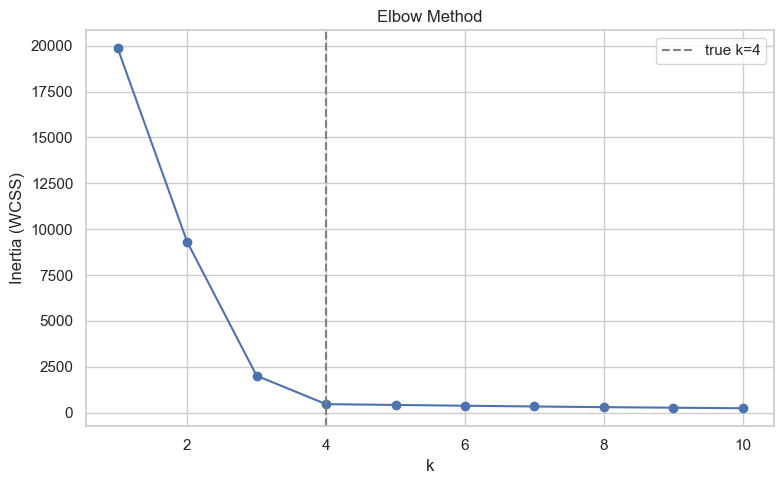

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_range, inertias, marker="o")
ax.axvline(4, color="gray", linestyle="--", label="true k=4")
ax.set_xlabel("k"); ax.set_ylabel("Inertia (WCSS)")
ax.set_title("Elbow Method")
ax.legend()
plt.tight_layout()
plt.show()


In [12]:
inertia_drops = [inertias[i] - inertias[i + 1] for i in range(len(inertias) - 1)]
print(f"Inertia drop from k=1->2: {inertia_drops[0]:.1f}")
print(f"Inertia drop from k=3->4: {inertia_drops[2]:.1f}")
print(f"Inertia drop from k=4->5: {inertia_drops[3]:.1f}")
print(f"-> The drop shrinks substantially right after k=4 (the true count), which is what an 'elbow' looks like -- though this method requires human judgment to read, unlike a cross-validated score.")


Inertia drop from k=1->2: 10553.3
Inertia drop from k=3->4: 1550.5
Inertia drop from k=4->5: 43.6
-> The drop shrinks substantially right after k=4 (the true count), which is what an 'elbow' looks like -- though this method requires human judgment to read, unlike a cross-validated score.


## 6. Choosing `k` — the Silhouette Score

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

where $a(i)$ is the mean distance from point $i$ to other points in its own cluster, and $b(i)$ is the mean distance to points in the nearest *other* cluster. Ranges from -1 (likely misassigned) to +1 (well-separated); unlike the elbow method, this gives one number per $k$ to directly compare, no visual judgment required.


In [13]:
silhouette_scores = []
for k in range(2, 11):
    model = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_blobs)
    score = silhouette_score(X_blobs, model.labels_)
    silhouette_scores.append({"k": k, "silhouette": round(score, 4)})
print(f"Computed silhouette score for k=2 through k=10.")


Computed silhouette score for k=2 through k=10.


In [14]:
silhouette_df = pd.DataFrame(silhouette_scores)
silhouette_df


,k,silhouette
0,2,0.5966
1,3,0.7676
2,4,0.8123
3,5,0.7087
4,6,0.5768
5,7,0.4395
6,8,0.3408
7,9,0.3512
8,10,0.3639


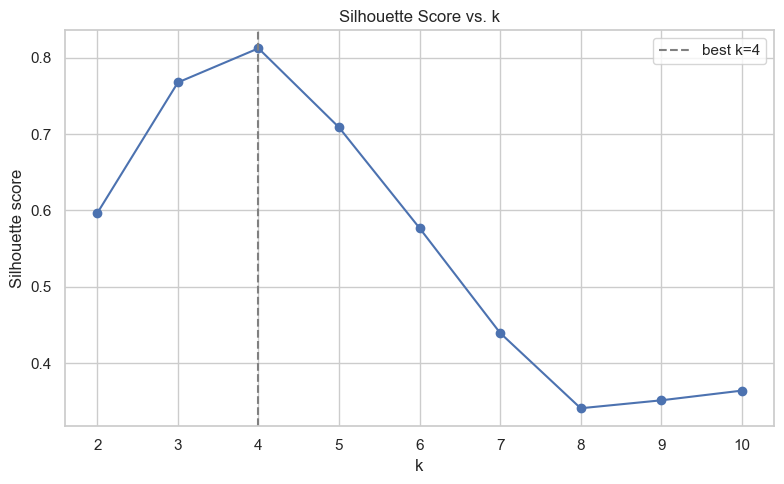

Silhouette-selected k=4 -- matches the true k=4 and the elbow method's visual read.


In [15]:
best_k_silhouette = silhouette_df.loc[silhouette_df["silhouette"].idxmax(), "k"]
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(silhouette_df["k"], silhouette_df["silhouette"], marker="o")
ax.axvline(best_k_silhouette, color="gray", linestyle="--", label=f"best k={best_k_silhouette}")
ax.set_xlabel("k"); ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette Score vs. k")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Silhouette-selected k={best_k_silhouette} -- {'matches' if best_k_silhouette == 4 else 'differs from'} the true k=4 and the elbow method's visual read.")


In [16]:
print("Comparing both k-selection methods on the same synthetic data with a known answer (k=4):")
print(f"  Elbow method:      requires visual judgment, but the sharpest drop happens right after k=4")
print(f"  Silhouette method: k={best_k_silhouette}, a single number requiring no judgment call")
print(f"  Ground truth:      k=4")
print("-> Silhouette is generally preferred in practice for exactly this reason -- it gives one comparable number per k rather than a plot that needs interpreting, though both agree here.")


Comparing both k-selection methods on the same synthetic data with a known answer (k=4):
  Elbow method:      requires visual judgment, but the sharpest drop happens right after k=4
  Silhouette method: k=4, a single number requiring no judgment call
  Ground truth:      k=4
-> Silhouette is generally preferred in practice for exactly this reason -- it gives one comparable number per k rather than a plot that needs interpreting, though both agree here.


## 7. Why Initialization Matters — Random Init vs. K-Means++

Lloyd's algorithm only finds a *local* optimum, and a poor random initialization can converge to a visibly worse clustering. K-Means++ initializes centroids to be spread apart deliberately, avoiding many of the worst cases.


In [17]:
random_init_inertias = []
kpp_init_inertias = []
for seed in range(20):
    model_random = KMeans(n_clusters=4, init="random", n_init=1, random_state=seed).fit(X_blobs)
    model_kpp = KMeans(n_clusters=4, init="k-means++", n_init=1, random_state=seed).fit(X_blobs)
    random_init_inertias.append(model_random.inertia_)
    kpp_init_inertias.append(model_kpp.inertia_)

print(f"Random init  -- mean inertia: {np.mean(random_init_inertias):.1f}, std: {np.std(random_init_inertias):.1f}, worst: {max(random_init_inertias):.1f}")
print(f"K-Means++    -- mean inertia: {np.mean(kpp_init_inertias):.1f}, std: {np.std(kpp_init_inertias):.1f}, worst: {max(kpp_init_inertias):.1f}")


Random init  -- mean inertia: 2241.3, std: 3017.3, worst: 13140.6
K-Means++    -- mean inertia: 458.8, std: 0.0, worst: 458.8


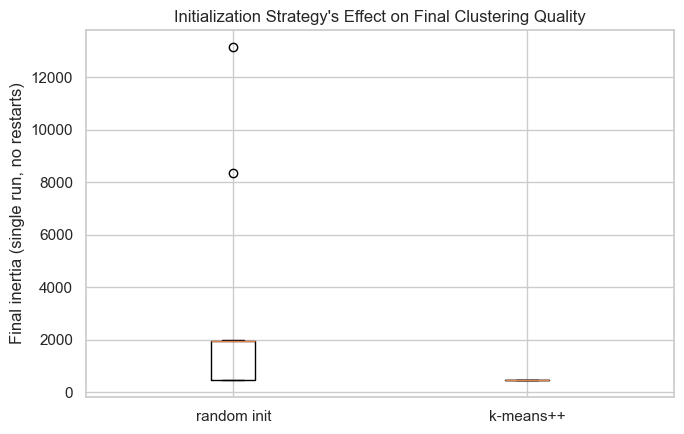

-> sklearn's default (init='k-means++', n_init=10) combines both fixes: smarter starting points AND multiple restarts, keeping only the best-inertia result.


In [18]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.boxplot([random_init_inertias, kpp_init_inertias], tick_labels=["random init", "k-means++"])
ax.set_ylabel("Final inertia (single run, no restarts)")
ax.set_title("Initialization Strategy's Effect on Final Clustering Quality")
plt.tight_layout()
plt.show()
print("-> sklearn's default (init='k-means++', n_init=10) combines both fixes: smarter starting points AND multiple restarts, keeping only the best-inertia result.")


## 8. K-Means' Core Limitation — Non-Spherical Clusters

K-Means implicitly assumes clusters are roughly spherical and similarly sized, because it only ever measures distance to a single centroid. Testing this assumption directly on data designed to violate it.


In [19]:
X_moons, y_moons_true = make_moons(n_samples=300, noise=0.08, random_state=42)
km_moons = KMeans(n_clusters=2, n_init=10, random_state=42).fit(X_moons)
ari_moons = adjusted_rand_score(y_moons_true, km_moons.labels_)
print(f"K-Means fit on interleaving-crescents data, ARI vs. true structure: {ari_moons:.4f}")


K-Means fit on interleaving-crescents data, ARI vs. true structure: 0.2610


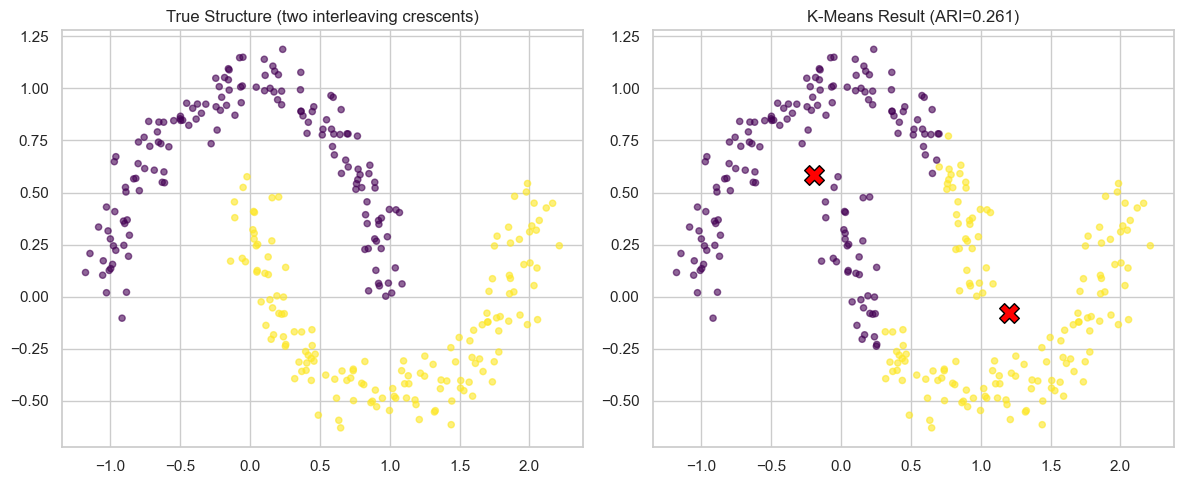

ARI dropped to 0.261 on non-spherical data (was 1.000 on spherical blobs) -- K-Means structurally cannot separate interleaving crescents, since no straight-line (Voronoi) boundary can. This is the direct motivation for DBSCAN and Gaussian Mixture Models, the next two topics.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons_true, cmap="viridis", alpha=0.6, s=20)
axes[0].set_title("True Structure (two interleaving crescents)")
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=km_moons.labels_, cmap="viridis", alpha=0.6, s=20)
axes[1].scatter(km_moons.cluster_centers_[:, 0], km_moons.cluster_centers_[:, 1], c="red", marker="X", s=200, edgecolors="black")
axes[1].set_title(f"K-Means Result (ARI={ari_moons:.3f})")
plt.tight_layout()
plt.show()
print(f"ARI dropped to {ari_moons:.3f} on non-spherical data (was {ari:.3f} on spherical blobs) -- K-Means structurally cannot separate interleaving crescents, since no straight-line (Voronoi) boundary can. This is the direct motivation for DBSCAN and Gaussian Mixture Models, the next two topics.")


## 9. Why K-Means Needs Feature Scaling

Distances between points determine everything in K-Means. A feature with a much larger numeric range will dominate the distance calculation regardless of its actual relevance -- the same issue seen with KNN and SVR's kernel.


In [21]:
X_unscaled_demo = np.column_stack([
    np.random.normal(0, 1, 200),
    np.random.normal(0, 1, 200),
])
X_unscaled_demo[:100, 1] += 5
X_unscaled_demo[100:, 1] -= 5
X_unscaled_demo[:, 0] *= 200

km_unscaled = KMeans(n_clusters=2, n_init=10, random_state=42).fit(X_unscaled_demo)
scaler_demo = StandardScaler().fit(X_unscaled_demo)
km_scaled = KMeans(n_clusters=2, n_init=10, random_state=42).fit(scaler_demo.transform(X_unscaled_demo))

true_split = np.array([0] * 100 + [1] * 100)
ari_unscaled = adjusted_rand_score(true_split, km_unscaled.labels_)
ari_scaled = adjusted_rand_score(true_split, km_scaled.labels_)
print(f"ARI on UNSCALED data (one feature artificially inflated x200): {ari_unscaled:.4f}")
print(f"ARI on SCALED data:                                            {ari_scaled:.4f}")
print("-> The real cluster-separating signal is in the second feature, but the first feature's inflated scale drowns it out entirely without scaling.")


ARI on UNSCALED data (one feature artificially inflated x200): 0.0050
ARI on SCALED data:                                            1.0000
-> The real cluster-separating signal is in the second feature, but the first feature's inflated scale drowns it out entirely without scaling.


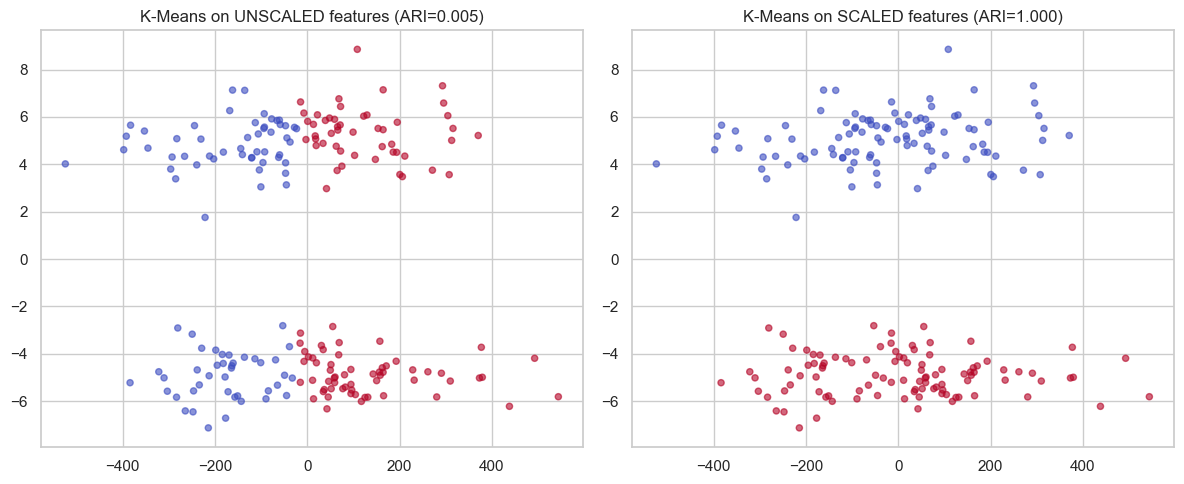

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_unscaled_demo[:, 0], X_unscaled_demo[:, 1], c=km_unscaled.labels_, cmap="coolwarm", alpha=0.6, s=20)
axes[0].set_title(f"K-Means on UNSCALED features (ARI={ari_unscaled:.3f})")
axes[1].scatter(X_unscaled_demo[:, 0], X_unscaled_demo[:, 1], c=km_scaled.labels_, cmap="coolwarm", alpha=0.6, s=20)
axes[1].set_title(f"K-Means on SCALED features (ARI={ari_scaled:.3f})")
plt.tight_layout()
plt.show()


## 10. Real Data Application — Iris, Without Labels

Clustering the Iris dataset using only its 4 measurements, then honestly checking the result against the true species labels (withheld from the algorithm, used only for post-hoc validation here).


In [23]:
scaler_iris = StandardScaler().fit(X_iris)
X_iris_scaled = scaler_iris.transform(X_iris)

iris_silhouettes = []
for k in range(2, 8):
    model = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_iris_scaled)
    iris_silhouettes.append({"k": k, "silhouette": round(silhouette_score(X_iris_scaled, model.labels_), 4)})
print(f"Computed Iris silhouette scores for k=2 through k=7.")


Computed Iris silhouette scores for k=2 through k=7.


In [24]:
iris_sil_df = pd.DataFrame(iris_silhouettes)
iris_sil_df


,k,silhouette
0,2,0.5818
1,3,0.4599
2,4,0.3869
3,5,0.3459
4,6,0.3171
5,7,0.3202


In [25]:
best_k_iris = iris_sil_df.loc[iris_sil_df["silhouette"].idxmax(), "k"]
print(f"Silhouette-selected k for Iris: {best_k_iris}")
print(f"True number of species: {len(iris.target_names)}")
if best_k_iris == len(iris.target_names):
    print("-> Silhouette analysis, using only the 4 measurements and no label information, recovered the correct number of true groups.")
else:
    print(f"-> Silhouette analysis selected k={best_k_iris}, not exactly {len(iris.target_names)} -- worth checking whether two species have measurements too similar to separate purely by distance (a real, known property of two Iris species).")


Silhouette-selected k for Iris: 2
True number of species: 3
-> Silhouette analysis selected k=2, not exactly 3 -- worth checking whether two species have measurements too similar to separate purely by distance (a real, known property of two Iris species).


In [26]:
km_iris_3 = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X_iris_scaled)
ari_iris = adjusted_rand_score(y_iris_true, km_iris_3.labels_)
crosstab_iris = pd.crosstab(pd.Series(y_iris_true, name="true species"), pd.Series(km_iris_3.labels_, name="k-means cluster"))
print(f"Adjusted Rand Index (k=3 vs. true species): {ari_iris:.4f}")
crosstab_iris


Adjusted Rand Index (k=3 vs. true species): 0.6201


k-means cluster,0,1,2
true species,,,
0,0,50,0
1,39,0,11
2,14,0,36


In [27]:
correct_assignments = crosstab_iris.values.max(axis=1).sum()
total_points = crosstab_iris.values.sum()
print(f"Taking each cluster's most common true species as its 'label': {correct_assignments}/{total_points} points ({correct_assignments/total_points:.1%}) fall in their cluster's majority species.")
print(f"This is a looser measure than ARI (it ignores mismatched pairs within the majority-agreement count) -- ARI ({ari_iris:.4f}) remains the more rigorous number to report.")


Taking each cluster's most common true species as its 'label': 125/150 points (83.3%) fall in their cluster's majority species.
This is a looser measure than ARI (it ignores mismatched pairs within the majority-agreement count) -- ARI (0.6201) remains the more rigorous number to report.


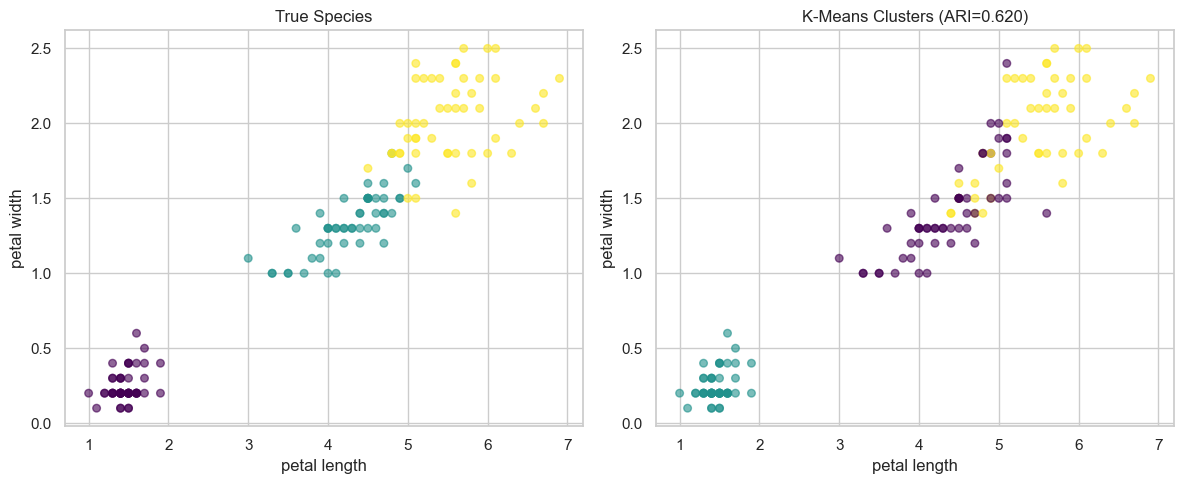

-> One species (setosa) is always cleanly separated in the petal measurements; the other two overlap more, which is precisely where the crosstab above shows most of the disagreement concentrated.


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_iris[:, 2], X_iris[:, 3], c=y_iris_true, cmap="viridis", alpha=0.6, s=30)
axes[0].set_xlabel("petal length"); axes[0].set_ylabel("petal width"); axes[0].set_title("True Species")
axes[1].scatter(X_iris[:, 2], X_iris[:, 3], c=km_iris_3.labels_, cmap="viridis", alpha=0.6, s=30)
axes[1].set_xlabel("petal length"); axes[1].set_ylabel("petal width"); axes[1].set_title(f"K-Means Clusters (ARI={ari_iris:.3f})")
plt.tight_layout()
plt.show()
print("-> One species (setosa) is always cleanly separated in the petal measurements; the other two overlap more, which is precisely where the crosstab above shows most of the disagreement concentrated.")


## 11. Silhouette Diagnostic Plot — Per-Point Detail

Beyond the single aggregate silhouette score, plotting every point's individual silhouette value reveals which specific cluster(s) are poorly separated.


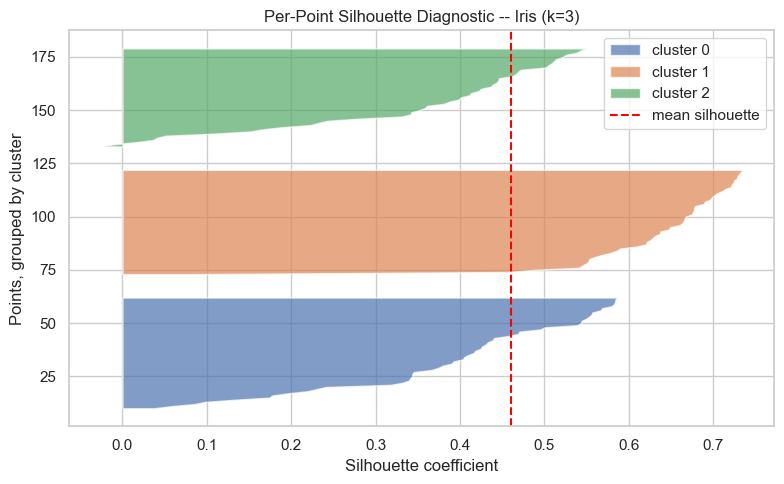

In [29]:
sample_silhouette_values = silhouette_samples(X_iris_scaled, km_iris_3.labels_)

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
for i in range(3):
    cluster_silhouette_values = sample_silhouette_values[km_iris_3.labels_ == i]
    cluster_silhouette_values.sort()
    size = len(cluster_silhouette_values)
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_values, alpha=0.7, label=f"cluster {i}")
    y_lower = y_upper + 10
ax.axvline(silhouette_score(X_iris_scaled, km_iris_3.labels_), color="red", linestyle="--", label="mean silhouette")
ax.set_xlabel("Silhouette coefficient"); ax.set_ylabel("Points, grouped by cluster")
ax.set_title("Per-Point Silhouette Diagnostic -- Iris (k=3)")
ax.legend()
plt.tight_layout()
plt.show()


In [30]:
min_silhouette_per_cluster = {i: round(sample_silhouette_values[km_iris_3.labels_ == i].min(), 3) for i in range(3)}
print(f"Minimum silhouette value per cluster: {min_silhouette_per_cluster}")
negative_count = np.sum(sample_silhouette_values < 0)
print(f"Points with NEGATIVE silhouette (likely misassigned): {negative_count}/{len(sample_silhouette_values)}")
print("-> Negative-silhouette points are exactly the ones in the crosstab's off-diagonal cells -- points geometrically closer to a neighboring cluster's centroid than their own.")


Minimum silhouette value per cluster: {0: np.float64(0.038), 1: np.float64(0.078), 2: np.float64(-0.025)}
Points with NEGATIVE silhouette (likely misassigned): 2/150
-> Negative-silhouette points are exactly the ones in the crosstab's off-diagonal cells -- points geometrically closer to a neighboring cluster's centroid than their own.


## 12. Summary

K-Means is fast, simple, and genuinely recovers real structure when that structure is roughly spherical and similarly scaled across clusters -- both cleanly demonstrated here (Section 4's near-perfect blob recovery, Section 10's partial-but-real Iris species recovery). Its core assumption is also its core limitation: Section 8 showed it structurally failing on non-spherical, interleaving data, motivating the next two topics (Hierarchical Clustering and DBSCAN), which drop the spherical-cluster assumption in different ways.

See [README.md](README.md) for the full mathematical derivations and a pitfalls reference.
